# 04. 회전계 파동: Kelvin파와 Rossby파

회전하는 천수계는 중력파 외에 두 가지 중요한 파동을 지지한다.

- **연안 Kelvin파**: 경계(해안)에 포획되어 한쪽 방향으로만 전파하는 비분산파.
  속도는 중력파와 같은 $c=\sqrt{gH}$, 횡방향으로는 변형반지름 $L_d$ 규모로
  지수감쇠하며, 북반구($f>0$)에서는 **해안을 오른쪽에 두고** 진행한다.
- **Rossby파**: $\beta$-효과($f$ 의 남북변화)가 복원력인 저주파파.
  위상은 항상 **서쪽으로** 전파한다. 대규모 해양 순환 조정의 핵심.

학습 목표:

1. 연안 Kelvin파의 비분산 전파·해안 포획·offshore 지수감쇠 재현
2. $\beta$-평면에서 Rossby파의 **서향 위상전파** 재현
3. 분산관계로부터의 위상속도와 모델 결과 비교

## 1. 라이브러리

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def find_project_root(markers=("pyproject.toml", ".git")):
    # 노트북에는 __file__ 이 없으므로 cwd 에서 위로 올라가며 루트를 찾는다.
    start = Path.cwd().resolve()
    for path in (start, *start.parents):
        if any((path / m).exists() for m in markers):
            return path
    return start.parent if start.name == "notebooks" else start


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

from shallow_water.grids.cgrid import CGrid
from shallow_water.dynamics.swe2d import ShallowWater2D
from shallow_water.utils.io import get_output_dirs

OUT = get_output_dirs(PROJECT_ROOT); FIG = OUT["figures"]
g, H = 9.81, 500.0

## 2. 연안 Kelvin파

Kelvin파는 횡방향 유속이 0($v=0$)이고, 해안에 직교한 방향으로 지형류 평형을
이룬다. 남쪽 벽($y=0$)을 해안으로 두면(앞바다는 $+y$), 해의 구조는

$$
\eta(x,y,t) = A\,G(x-ct)\,e^{-y/L_d},\qquad u=\frac{c}{H}\eta,\qquad v=0
$$

이다. 북반구에서 이 파동은 **동쪽(+x)**, 즉 해안을 오른쪽에 두고 진행한다.
$x$ 방향은 주기경계(긴 해안), $y$ 방향은 벽으로 둔다.

In [2]:
f0 = 1e-4
Lx, Ly, nx, ny = 4e6, 2e6, 200, 80
grid = CGrid(nx=nx, ny=ny, Lx=Lx, Ly=Ly, periodic_x=True)
model = ShallowWater2D(grid=grid, g=g, H=H, f0=f0)
c = model.gravity_wave_speed(); Ld = model.deformation_radius()
X, Y = grid.meshgrid_eta()

A, xc, Wx = 0.5, Lx / 2, 3e5
eta0 = A * np.exp(-((X - xc) / Wx) ** 2) * np.exp(-Y / Ld)
# u = (c/H) eta, eta 를 u-face 로 보간 (주기 x)
eta_u = np.zeros((ny, nx + 1))
eta_u[:, 1:-1] = 0.5 * (eta0[:, 1:] + eta0[:, :-1])
eta_u[:, 0] = 0.5 * (eta0[:, 0] + eta0[:, -1]); eta_u[:, -1] = eta_u[:, 0]
u0 = (c / H) * eta_u
v0 = np.zeros((ny + 1, nx))

dt = 0.4 * grid.dx / (c * np.sqrt(2))
T = 0.6 * Lx / c
nsteps = int(round(T / dt))
res = model.run(eta0, u0, v0, dt, nsteps=nsteps, save_every=max(1, nsteps // 120),
                track_energy=False)
print(f"c = {c:.0f} m/s, Ld = {Ld/1e3:.0f} km, {nsteps} steps")

c = 70 m/s, Ld = 700 km, 424 steps


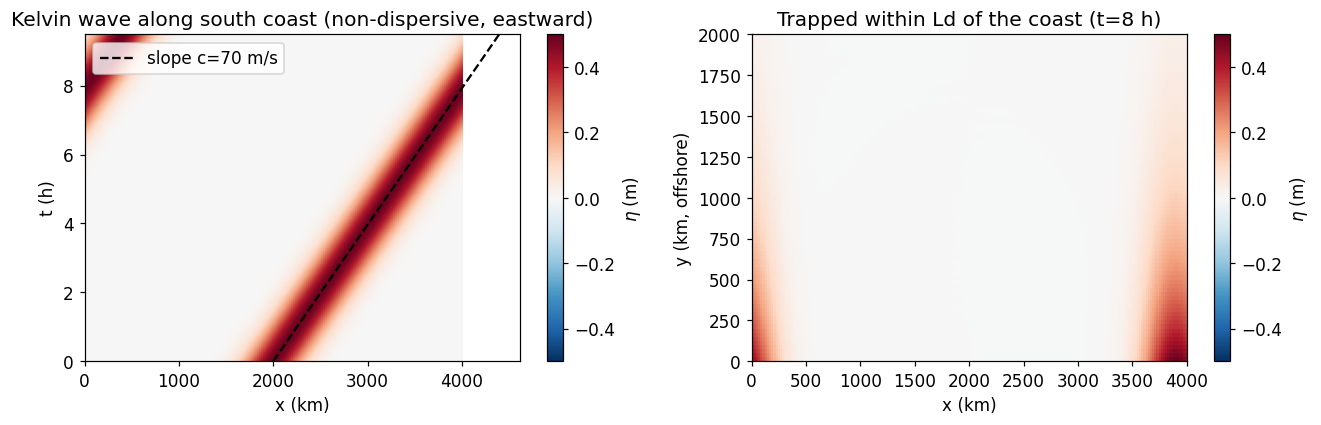

In [3]:
xs, t = grid.x_eta / 1e3, res["save_times"]
coast = np.array([h[0] for h in res["eta_hist"]])   # 남쪽 벽 행
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(coast, aspect="auto", origin="lower", cmap="RdBu_r",
                    extent=[0, Lx/1e3, 0, t[-1]/3600], vmin=-A, vmax=A)
# 이론 위상선 (slope = 1/c)
x_line = np.array([xc/1e3, xc/1e3 + c*t[-1]/1e3])
axes[0].plot(x_line, [0, t[-1]/3600], "k--", lw=1.5, label=f"slope c={c:.0f} m/s")
axes[0].set_xlabel("x (km)"); axes[0].set_ylabel("t (h)")
axes[0].set_title("Kelvin wave along south coast (non-dispersive, eastward)")
axes[0].legend(loc="upper left"); fig.colorbar(im, ax=axes[0], label=r"$\eta$ (m)")

# 스냅샷: 초기와 후기 (동쪽으로 이동, 모양 유지)
kf = int(0.8 * (len(res["eta_hist"]) - 1))
im2 = axes[1].pcolormesh(xs, grid.y_eta/1e3, res["eta_hist"][kf], cmap="RdBu_r",
                         vmin=-A, vmax=A, shading="auto")
axes[1].set_xlabel("x (km)"); axes[1].set_ylabel("y (km, offshore)")
axes[1].set_title(f"Trapped within Ld of the coast (t={t[kf]/3600:.0f} h)")
fig.colorbar(im2, ax=axes[1], label=r"$\eta$ (m)")
fig.tight_layout(); fig.savefig(FIG / "04_kelvin_propagation.png", bbox_inches="tight"); plt.show()

### offshore 지수감쇠

해안에서 멀어질수록 진폭이 $e^{-y/L_d}$ 로 감쇠한다.

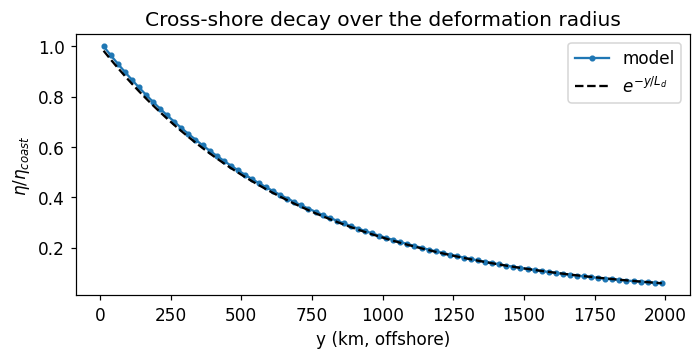

측정 감쇠규모 = 700 km  (이론 Ld = 700 km)


In [4]:
kf = res["eta_hist"][-1]
col = np.argmax(kf[0])
prof = kf[:, col]
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(grid.y_eta/1e3, prof/prof[0], "C0o-", ms=3, label="model")
ax.plot(grid.y_eta/1e3, np.exp(-grid.y_eta/Ld), "k--", label=r"$e^{-y/L_d}$")
ax.set_xlabel("y (km, offshore)"); ax.set_ylabel(r"$\eta / \eta_{coast}$")
ax.set_title("Cross-shore decay over the deformation radius"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "04_kelvin_decay.png", bbox_inches="tight"); plt.show()
fit = np.polyfit(grid.y_eta[:30], np.log(np.abs(prof[:30]) + 1e-12), 1)
print(f"측정 감쇠규모 = {-1/fit[0]/1e3:.0f} km  (이론 Ld = {Ld/1e3:.0f} km)")

## 3. Rossby파 — 서향 위상전파

$\beta$-평면($f=f_0+\beta y$)에서 위치소용돌이도 보존이 복원력으로 작용해
**Rossby파**가 생긴다. 북쪽으로 이동한 유체기둥은 행성소용돌이도가 커지므로
상대소용돌이도가 음(시계방향)이 되어야 하고, 이 유도된 흐름이 패턴을
**서쪽으로** 밀어낸다.

분산관계(자유표면 포함):

$$
\omega = \frac{-\beta\,k}{k^2+l^2+L_d^{-2}},\qquad
c_x = \frac{\omega}{k} = \frac{-\beta}{k^2+l^2+L_d^{-2}} < 0.
$$

$\beta$-평면 채널(주기 $x$, 벽 $y$)에 대규모 패턴 $\eta=A\cos(kx)\sin(ly)$ 을
지형류 평형으로 놓고 적분한다.

In [5]:
beta = 2e-11
Lx, Ly, n = 4e6, 4e6, 120
grid = CGrid(nx=n, ny=n, Lx=Lx, Ly=Ly, periodic_x=True)
model = ShallowWater2D(grid=grid, g=g, H=H, f0=f0, beta=beta)
c = model.gravity_wave_speed(); Ld = c / f0
X, Y = grid.meshgrid_eta()
k, l = 2*np.pi/Lx, np.pi/Ly
A = 0.3
eta0 = A * np.cos(k * X) * np.sin(l * Y)

# 지형류 평형 초기조건 (국지 f) → 느린 Rossby 모드 위주로 여기
fc = f0 + beta * (Y - Ly/2)
detadx = np.gradient(eta0, grid.dx, axis=1)
detady = np.gradient(eta0, grid.dy, axis=0)
uc, vc = -(g/fc)*detady, (g/fc)*detadx
u0 = np.zeros((n, n+1)); u0[:, 1:-1] = 0.5*(uc[:, 1:]+uc[:, :-1])
u0[:, 0] = 0.5*(uc[:, 0]+uc[:, -1]); u0[:, -1] = u0[:, 0]
v0 = np.zeros((n+1, n)); v0[1:-1, :] = 0.5*(vc[1:, :]+vc[:-1, :])

cR = -beta / (k**2 + l**2 + 1/Ld**2)
dt = 0.4 * grid.dx / (c * np.sqrt(2))
Tend = abs(Lx / 2 / cR)              # 위상이 반 파장 서진할 시간
nsteps = int(round(Tend / dt))
res = model.run(eta0, u0, v0, dt, nsteps=nsteps, save_every=max(1, nsteps // 120),
                track_energy=False)
print(f"theory cR = {cR:.2f} m/s (서향), {nsteps} steps, T = {Tend/86400:.1f} days")

theory cR = -3.90 m/s (서향), 3806 steps, T = 5.9 days


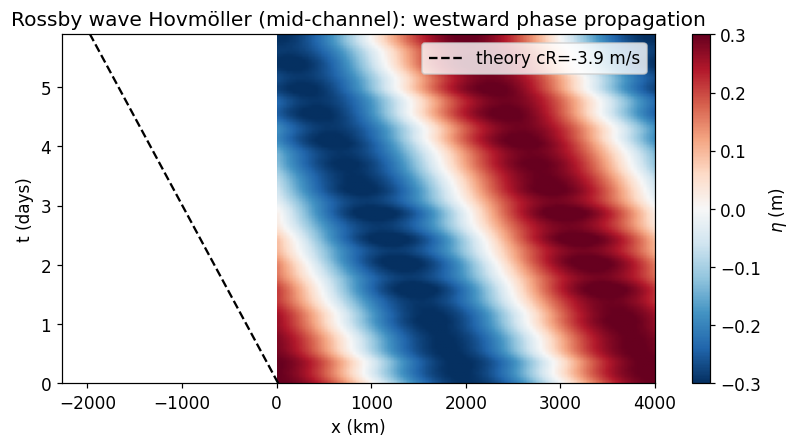

측정 위상속도 = -3.94 m/s  (이론 -3.90 m/s, 음수=서향)


In [6]:
xs, t = grid.x_eta/1e3, res["save_times"]
jmid = n // 2
hov = np.array([h[jmid] for h in res["eta_hist"]])
fig, ax = plt.subplots(figsize=(7.5, 4.2))
im = ax.imshow(hov, aspect="auto", origin="lower", cmap="RdBu_r",
               extent=[0, Lx/1e3, 0, t[-1]/86400], vmin=-A, vmax=A)
# 이론 서향 위상선 (음의 기울기)
x0 = xs[np.argmax(hov[0])]
ax.plot([x0, x0 + cR*t[-1]/1e3], [0, t[-1]/86400], "k--", lw=1.5,
        label=f"theory cR={cR:.1f} m/s")
ax.set_xlabel("x (km)"); ax.set_ylabel("t (days)")
ax.set_title("Rossby wave Hovmöller (mid-channel): westward phase propagation")
ax.legend(loc="upper right"); fig.colorbar(im, ax=ax, label=r"$\eta$ (m)")
fig.tight_layout(); fig.savefig(FIG / "04_rossby_hovmoller.png", bbox_inches="tight"); plt.show()

# 위상속도 측정 (max 위치 추적 + unwrap)
peakx = np.array([grid.x_eta[np.argmax(h[jmid])] for h in res["eta_hist"]])
px = np.unwrap(peakx/Lx*2*np.pi)/(2*np.pi)*Lx
speed = np.polyfit(t, px, 1)[0]
print(f"측정 위상속도 = {speed:.2f} m/s  (이론 {cR:.2f} m/s, 음수=서향)")

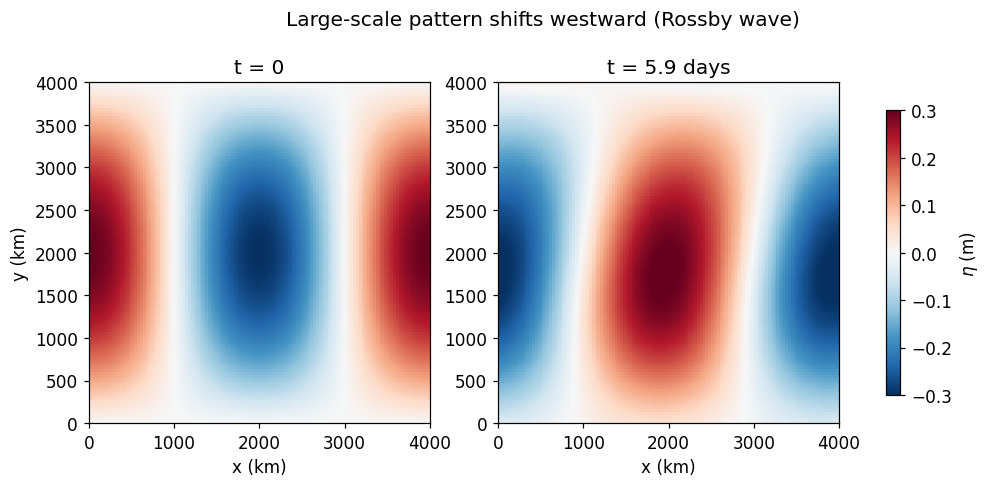

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, kk, lab in zip(axes, [0, len(res["eta_hist"])-1], ["t = 0", f"t = {t[-1]/86400:.1f} days"]):
    im = ax.pcolormesh(xs, grid.y_eta/1e3, res["eta_hist"][kk], cmap="RdBu_r",
                       vmin=-A, vmax=A, shading="auto")
    ax.set_title(lab); ax.set_xlabel("x (km)"); ax.set_aspect("equal")
axes[0].set_ylabel("y (km)")
fig.colorbar(im, ax=axes, label=r"$\eta$ (m)", shrink=0.8)
fig.suptitle("Large-scale pattern shifts westward (Rossby wave)", y=1.02)
fig.savefig(FIG / "04_rossby_snapshots.png", bbox_inches="tight"); plt.show()

## 4. 정리

- **연안 Kelvin파**: 해안에 포획되어 비분산으로 $c=\sqrt{gH}$ 로 전파하고,
  앞바다로는 $e^{-y/L_d}$ 로 감쇠하며, 북반구에서 해안을 오른쪽에 두고 진행한다.
- **Rossby파**: $\beta$-효과가 복원하는 저주파파로 위상이 항상 서쪽으로 가며,
  측정 위상속도가 분산관계 $c_x=-\beta/(k^2+l^2+L_d^{-2})$ 와 일치한다.
- 두 파동 모두 해양의 대규모 조정·서안경계강화와 직결된다 — 다음 Stage 의 주제.

다음(Stage 5)에서는 바람 강제와 마찰을 더해 **풍성순환(Stommel·Munk gyre)** 과
서안경계강화를 재현한다.